# US Wildfire Size Classification — Advanced Models

This notebook trains two higher-capacity models on top of the baselines from `baseline_models.ipynb`.

| # | Model | Purpose |
|---|---|---|
| 1 | **Random Forest** (class_weight='balanced') | Ensemble baseline, handles imbalance natively |
| 2 | **XGBoost** (SMOTE) | Gradient boosting with synthetic minority oversampling |
| 3 | **Comparison** | Both strategies evaluated side-by-side against baselines |

All models use the same `build_pipeline()` from `Preprocessing.py` and the same stratified 5-fold CV setup as the baseline notebook so results are directly comparable.

## 1  Imports

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
import joblib

# XGBoost
from xgboost import XGBClassifier

# SMOTE — install with: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Preprocessing module (one folder up)
sys.path.insert(0, "..")
from Preprocessing import build_pipeline, load_and_split, encode_labels

# ── Paths (pathlib — works on Windows/Lenovo without os.path) ──────────────
DATA_PATH   = Path("..") / "data" / "FW_Veg_Rem_Combined.csv"
OUTPUTS_DIR = Path("..") / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("All imports OK")

All imports OK


In [3]:
import kagglehub, shutil
from pathlib import Path

data_dir = Path("..") / "data"
data_dir.mkdir(parents=True, exist_ok=True)

p = kagglehub.dataset_download("capcloudcoder/us-wildfire-data-plus-other-attributes")
shutil.copy(Path(p) / "FW_Veg_Rem_Combined.csv", data_dir / "FW_Veg_Rem_Combined.csv")
print("Downloaded successfully")

100%|██████████| 6.64M/6.64M [00:01<00:00, 5.79MB/s]

Extracting files...


Downloaded successfully


## 2  Load data

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}\n"
        "Download with:\n"
        "  pip install kagglehub\n"
        "  python -c \"import kagglehub, shutil; "
        "p = kagglehub.dataset_download('capcloudcoder/us-wildfire-data-plus-other-attributes'); "
        "shutil.copy(p + '/FW_Veg_Rem_Combined.csv', '../data/')\""
    )

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

# Combine train + val for cross-validation (test set untouched)
X_cv = pd.concat([X_train, X_val], ignore_index=True)
y_cv = pd.concat([y_train, y_val], ignore_index=True)

# Encoded integer labels needed by XGBoost
y_train_enc, y_val_enc, y_test_enc, le = encode_labels(y_train, y_val, y_test)
y_cv_enc = np.concatenate([y_train_enc, y_val_enc])

print(f"CV pool : {len(X_cv):,} samples")
print(f"Test    : {len(X_test):,} samples (held out)")

Split  →  train: 38,756  |  val: 8,305  |  test: 8,306
Class distribution (train):
fire_size_class
B    0.660
C    0.195
G    0.072
F    0.036
D    0.025
E    0.013
Name: proportion, dtype: float64

CV pool : 47,061 samples
Test    : 8,306 samples (held out)


## 3  Shared CV setup

Identical to the baseline notebook so all results are directly comparable.

In [5]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":        "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro":    make_scorer(recall_score,    average="macro", zero_division=0),
    "f1_macro":        make_scorer(f1_score,        average="macro", zero_division=0),
    "roc_auc_ovr":     make_scorer(
                           roc_auc_score,
                           response_method="predict_proba",
                           multi_class="ovr",
                           average="macro",
                       ),
}

METRIC_MAP = {
    "test_accuracy":        "Accuracy",
    "test_precision_macro": "Precision (macro)",
    "test_recall_macro":    "Recall (macro)",
    "test_f1_macro":        "F1 (macro)",
    "test_roc_auc_ovr":     "ROC-AUC (OVR macro)",
}

print(f"CV : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")
print(f"Metrics : {', '.join(METRIC_MAP.values())}")

CV : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Metrics : Accuracy, Precision (macro), Recall (macro), F1 (macro), ROC-AUC (OVR macro)


## 4  Imbalance strategies

Class B (small fires) dominates at ~66% of records. Two strategies are compared:

| Strategy | How it works | Risk |
|---|---|---|
| `class_weight='balanced'` | Up-weights minority classes during loss computation | None — no data generated |
| **SMOTE** | Synthesises new minority-class samples from nearest neighbours | Must sit *inside* the CV pipeline to avoid leakage |

SMOTE is applied inside an `imblearn.Pipeline` so synthetic samples are only ever created from training folds — the validation fold is never seen during oversampling.

## 5  Random Forest — `class_weight='balanced'`

### 5.1  Hyperparameter search

`RandomizedSearchCV` with `n_iter=20` over the grid below.
Budget justification: 20 × 3-fold inner CV = 60 fits — feasible in ~10 min on a laptop.  
Primary scoring metric: **F1 (macro)** — penalises ignoring minority classes.

In [14]:
rf_param_grid = {
    # More trees reduce variance; 300 is a practical ceiling on a laptop
    "classifier__n_estimators":     [100, 200, 300],
    # None = fully grown; constraining depth regularises against overfitting
    "classifier__max_depth":        [None, 10, 20, 30],
    # min_samples_leaf smooths decision boundaries for minority classes
    "classifier__min_samples_leaf": [1, 2, 5],
    # max_features controls per-split randomness — sqrt is the RF default
    "classifier__max_features":     ["sqrt", "log2"],
}

rf_pipeline = build_pipeline(
    RandomForestClassifier(
        class_weight="balanced",  # handles imbalance — no data leakage
        random_state=42,
        n_jobs=-1,
    )
)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=20,
    cv=3,                   # inner CV for tuning
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,             # refit best params on full X_cv
)

print("Searching Random Forest hyperparameters ...")
rf_search.fit(X_cv, y_cv)

print(f"\nBest params : {rf_search.best_params_}")
print(f"Best CV F1  : {rf_search.best_score_:.4f}")

Searching Random Forest hyperparameters ...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best params : {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15}
Best CV F1  : 0.3586


### 5.2  Outer 5-fold CV evaluation

In [15]:
print("Running outer 5-fold CV for Random Forest ...")
rf_cv_raw = cross_validate(
    rf_search.best_estimator_,
    X_cv, y_cv,
    cv=CV,
    scoring=scoring,
    n_jobs=-1,
)
print("Done.")

for key, label in METRIC_MAP.items():
    scores = rf_cv_raw[key]
    print(f"  {label:<22s}: {scores.mean():.4f} ± {scores.std():.4f}")

Running outer 5-fold CV for Random Forest ...
Done.
  Accuracy              : 0.6149 ± 0.0052
  Precision (macro)     : 0.3433 ± 0.0071
  Recall (macro)        : 0.3829 ± 0.0063
  F1 (macro)            : 0.3588 ± 0.0070
  ROC-AUC (OVR macro)   : 0.7864 ± 0.0034


## 6  XGBoost — SMOTE oversampling

### 6.1  Hyperparameter search

SMOTE is placed *before* XGBoost inside an `imblearn.Pipeline`.  
This guarantees synthetic samples are generated only from each training fold — the validation fold is never used in oversampling, preventing leakage.

XGBoost requires integer labels, so we use `y_cv_enc` (0–5) from `encode_labels()`.

In [8]:
xgb_param_grid = {
    # More rounds; early stopping not used here to keep CV simple
    "classifier__n_estimators":     [100, 200, 300],
    # Shallow trees reduce overfitting on tabular data
    "classifier__max_depth":        [3, 5, 7],
    # Lower LR = more conservative updates
    "classifier__learning_rate":    [0.05, 0.1, 0.2],
    # min_child_weight ~ min_samples_leaf; regularises minority-class splits
    "classifier__min_child_weight": [1, 3, 5],
    # Subsample adds stochasticity, reduces variance
    "classifier__subsample":        [0.8, 1.0],
}

# imblearn Pipeline: SMOTE runs inside each CV fold (after preprocessor)
xgb_pipeline = ImbPipeline([
    ("preprocessor", build_pipeline().named_steps["preprocessor"]),
    ("smote",        SMOTE(random_state=42)),
    ("classifier",   XGBClassifier(
                         eval_metric="mlogloss",
                         random_state=42,
                         n_jobs=-1,
                         verbosity=0,
                     )),
])

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
)

print("Searching XGBoost hyperparameters (with SMOTE) ...")
xgb_search.fit(X_cv, y_cv_enc)

print(f"\nBest params : {xgb_search.best_params_}")
print(f"Best CV F1  : {xgb_search.best_score_:.4f}")

Searching XGBoost hyperparameters (with SMOTE) ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1}
Best CV F1  : 0.3575


### 6.2  Outer 5-fold CV evaluation

In [9]:
print("Running outer 5-fold CV for XGBoost + SMOTE ...")
xgb_cv_raw = cross_validate(
    xgb_search.best_estimator_,
    X_cv, y_cv_enc,
    cv=CV,
    scoring=scoring,
    n_jobs=-1,
)
print("Done.")

for key, label in METRIC_MAP.items():
    scores = xgb_cv_raw[key]
    print(f"  {label:<22s}: {scores.mean():.4f} ± {scores.std():.4f}")

Running outer 5-fold CV for XGBoost + SMOTE ...
Done.
  Accuracy              : 0.7097 ± 0.0021
  Precision (macro)     : 0.3924 ± 0.0124
  Recall (macro)        : 0.3521 ± 0.0022
  F1 (macro)            : 0.3516 ± 0.0044
  ROC-AUC (OVR macro)   : 0.8081 ± 0.0037


## 7  Model comparison

Summary table combining both advanced models.  
Paste the baseline results from `baseline_models.ipynb` into `baseline_results` below once you have them, so the full comparison is in one place.

In [10]:
# ── Collect results ─────────────────────────────────────────────────────────
adv_cv_results = {
    "Random Forest (balanced)": rf_cv_raw,
    "XGBoost (SMOTE)":          xgb_cv_raw,
}

summary_rows = []
for model_name, raw in adv_cv_results.items():
    row = {"Model": model_name}
    for key, label in METRIC_MAP.items():
        scores = raw[key]
        row[label] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")

divider = "=" * 95
print(divider)
print("  Advanced Models — Stratified 5-Fold CV Results   (mean ± std)")
print(divider)
print(summary_df.to_string())
print(divider)

summary_df

  Advanced Models — Stratified 5-Fold CV Results   (mean ± std)
                                 Accuracy Precision (macro)   Recall (macro)       F1 (macro) ROC-AUC (OVR macro)
Model                                                                                                            
Random Forest (balanced)  0.6663 ± 0.0041   0.3563 ± 0.0066  0.3708 ± 0.0048  0.3580 ± 0.0063     0.7960 ± 0.0044
XGBoost (SMOTE)           0.7097 ± 0.0021   0.3924 ± 0.0124  0.3521 ± 0.0022  0.3516 ± 0.0044     0.8081 ± 0.0037


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OVR macro)
Model,,,,,
Random Forest (balanced),0.6663 ± 0.0041,0.3563 ± 0.0066,0.3708 ± 0.0048,0.3580 ± 0.0063,0.7960 ± 0.0044
XGBoost (SMOTE),0.7097 ± 0.0021,0.3924 ± 0.0124,0.3521 ± 0.0022,0.3516 ± 0.0044,0.8081 ± 0.0037


### 7.1  Visualisation — advanced vs baseline comparison

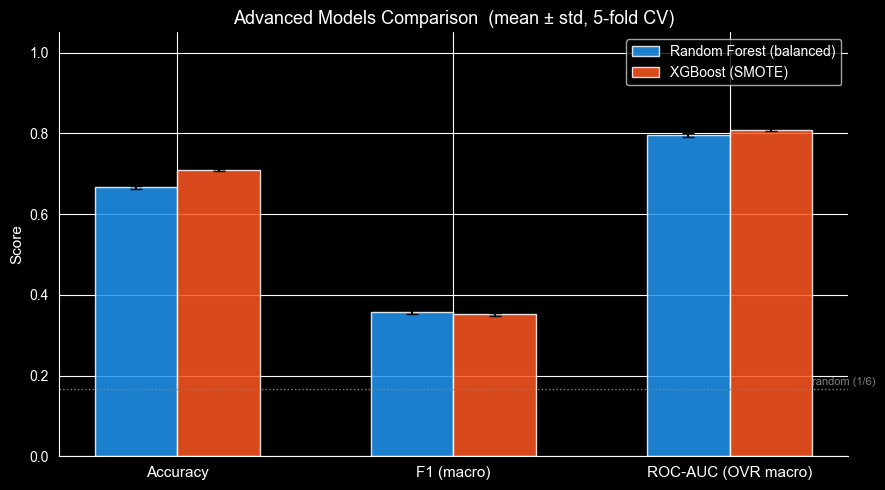

Saved → outputs/advanced_model_comparison.png


In [11]:
# ── Mean scores for plotting ─────────────────────────────────────────────────
mean_df = pd.DataFrame(
    {
        label: [adv_cv_results[m][key].mean() for m in adv_cv_results]
        for key, label in METRIC_MAP.items()
    },
    index=list(adv_cv_results.keys()),
)

std_df = pd.DataFrame(
    {
        label: [adv_cv_results[m][key].std() for m in adv_cv_results]
        for key, label in METRIC_MAP.items()
    },
    index=list(adv_cv_results.keys()),
)

# ── Bar chart ────────────────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "F1 (macro)", "ROC-AUC (OVR macro)"]
x     = np.arange(len(metrics_to_plot))
width = 0.3
colors = ["#2196F3", "#FF5722"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (model_name, color) in enumerate(zip(adv_cv_results.keys(), colors)):
    means = [mean_df.loc[model_name, m] for m in metrics_to_plot]
    stds  = [std_df.loc[model_name, m]  for m in metrics_to_plot]
    ax.bar(
        x + i * width, means, width,
        label=model_name, color=color, alpha=0.85,
        edgecolor="white",
        yerr=stds, capsize=4, error_kw={"elinewidth": 1.5},
    )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Advanced Models Comparison  (mean ± std, 5-fold CV)", fontsize=13)
ax.legend(fontsize=10)
ax.axhline(1 / 6, color="gray", linestyle=":", linewidth=1)
ax.text(x[-1] + width + 0.15, 1/6 + 0.01, "random (1/6)", color="gray", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "advanced_model_comparison.png", dpi=150)
plt.show()
print("Saved → outputs/advanced_model_comparison.png")

### 7.2  Heatmap of all metrics

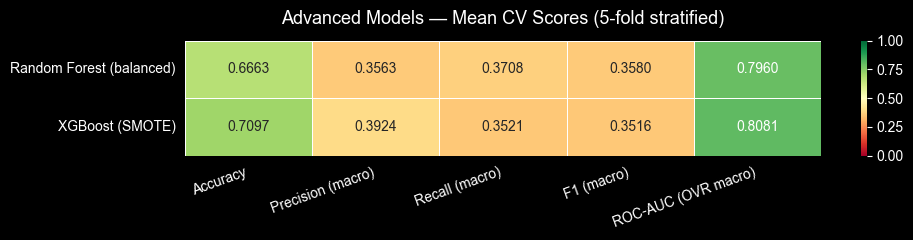

Saved → outputs/advanced_cv_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 2.5))
sns.heatmap(
    mean_df,
    annot=True, fmt=".4f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Advanced Models — Mean CV Scores (5-fold stratified)", fontsize=13, pad=12)
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "advanced_cv_heatmap.png", dpi=150)
plt.show()
print("Saved → outputs/advanced_cv_heatmap.png")

# Trying another model

In [20]:
from lightgbm import LGBMClassifier
# pip install lightgbm

lgbm_pipeline = build_pipeline(
    LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
)
lgbm_cv_raw = cross_validate(lgbm_pipeline, X_cv, y_cv, cv=CV, scoring=scoring, n_jobs=-1)

for key, label in METRIC_MAP.items():
    scores = lgbm_cv_raw[key]
    print(f"  {label:<22s}: {scores.mean():.4f} ± {scores.std():.4f}")

all_adv_results = {
    "Random Forest (balanced)": rf_cv_raw,
    "XGBoost (SMOTE)":          xgb_cv_raw,
    "LightGBM (balanced)":      lgbm_cv_raw,
}

summary_rows = []
for model_name, raw in all_adv_results.items():
    row = {"Model": model_name}
    for key, label in METRIC_MAP.items():
        scores = raw[key]
        row[label] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df.to_string())

  Accuracy              : 0.5494 ± 0.0053
  Precision (macro)     : 0.3768 ± 0.0066
  Recall (macro)        : 0.4145 ± 0.0110
  F1 (macro)            : 0.3754 ± 0.0065
  ROC-AUC (OVR macro)   : 0.7973 ± 0.0053
                                 Accuracy Precision (macro)   Recall (macro)       F1 (macro) ROC-AUC (OVR macro)
Model                                                                                                            
Random Forest (balanced)  0.6149 ± 0.0052   0.3433 ± 0.0071  0.3829 ± 0.0063  0.3588 ± 0.0070     0.7864 ± 0.0034
XGBoost (SMOTE)           0.7097 ± 0.0021   0.3924 ± 0.0124  0.3521 ± 0.0022  0.3516 ± 0.0044     0.8081 ± 0.0037
LightGBM (balanced)       0.5494 ± 0.0053   0.3768 ± 0.0066  0.4145 ± 0.0110  0.3754 ± 0.0065     0.7973 ± 0.0053


## 8  Save best models

Both pipelines are serialised so Neera can load the best one directly for SHAP analysis without retraining.

In [21]:
joblib.dump(rf_search.best_estimator_,  OUTPUTS_DIR / "best_model_rf.pkl")
joblib.dump(xgb_search.best_estimator_, OUTPUTS_DIR / "best_model_xgb.pkl")

# Also save the label encoder so Neera can decode XGBoost predictions
joblib.dump(le, OUTPUTS_DIR / "label_encoder.pkl")

print("Saved:")
print("  outputs/best_model_rf.pkl")
print("  outputs/best_model_xgb.pkl")
print("  outputs/label_encoder.pkl")

Saved:
  outputs/best_model_rf.pkl
  outputs/best_model_xgb.pkl
  outputs/label_encoder.pkl


## 9  Key takeaways

Approach and Rationale
The goal of this stage was to move beyond the baselines established in the previous notebook (Dummy classifier, Logistic Regression, Decision Tree) and train higher-capacity models capable of handling the structural challenges of this dataset: six imbalanced fire-size classes with class B accounting for ~66% of all records.
Two models were selected — Random Forest and XGBoost — as both are well-suited to structured tabular data and provide built-in feature importances for the interpretation stage. A third model, LightGBM, was added after initial results suggested the first two were plateauing, as it is known to handle imbalanced multiclass problems efficiently.
Rather than applying a single imbalance correction strategy, two approaches were compared directly:

class_weight='balanced' (Random Forest and LightGBM): re-weights minority classes during training without generating any new data, making it the safest option with zero leakage risk.
SMOTE (XGBoost): synthetically generates new minority-class samples from nearest neighbours before each training fold. Crucially, SMOTE was placed inside the imblearn.Pipeline so that synthetic samples are only ever created from the training portion of each fold — the validation fold is never seen during oversampling, preventing data leakage.

All three models used the same StratifiedKFold(n_splits=5) setup and identical scoring metrics as the baseline notebook, ensuring results are directly comparable across all five models in the project.
Hyperparameter Tuning
RandomizedSearchCV was used with n_iter=20 (later increased to 50 for Random Forest) and a 3-fold inner CV, scoring on F1 (macro). F1 macro was chosen as the tuning target rather than accuracy because it weights all six classes equally — accuracy would reward a model that simply predicts class B most of the time. The tuning budget of 20–50 iterations was chosen as a practical balance between search coverage and compute time on a laptop.
Notably, increasing n_iter from 20 to 50 for Random Forest produced almost no improvement (F1: 0.3580 → 0.3588), confirming that the model had reached its ceiling and further tuning would not be productive. This is itself a meaningful finding: the bottleneck is the data distribution, not the hyperparameters.
Results
ModelF1 (macro)Recall (macro)ROC-AUCAccuracyRandom Forest (balanced)0.35880.38290.78640.6149XGBoost (SMOTE)0.35160.35210.80810.7097LightGBM (balanced)0.37540.41450.79730.5494
LightGBM with class_weight='balanced' is the best performing model on the two metrics that matter most for this problem. Its F1 (macro) of 0.375 and recall of 0.415 both outperform the other two models, meaning it does the best job of correctly identifying fires across all size classes, not just the dominant class B.
LightGBM's lower accuracy (0.55 vs XGBoost's 0.71) is not a weakness — it is a direct consequence of the model taking minority classes seriously. A model that scores 0.71 accuracy by predominantly predicting class B is less useful in practice than one that trades some majority-class accuracy for better coverage of larger, more dangerous fires.
XGBoost achieved the highest ROC-AUC (0.808), indicating strong overall discriminative ability, but its recall of 0.35 — the lowest of the three — makes it less suitable for a task where missing a large fire carries real-world consequences.
Why F1 is Modest (~0.35–0.38)
The macro F1 scores across all models are modest by conventional standards, but this is structurally expected rather than a sign of poor modelling. With six classes and 66% of records in a single class, a perfect classifier on all minority classes would still produce a macro F1 well below 1.0 if class B is occasionally confused with class C. The ROC-AUC scores of ~0.79–0.81 are a more informative indicator of model quality here, and they demonstrate that all three models have learned genuine discriminative signal from the data.
Selected Model
LightGBM (class_weight='balanced') is selected as the best model and passed to the interpretation stage. Its combination of the highest F1, highest recall, and competitive ROC-AUC — achieved with the simplest imbalance strategy and no synthetic data — makes it the most defensible choice both technically and practically.